<a href="https://colab.research.google.com/github/poojasukhdeve-project/SPY-ETF-Machine-Learning-Trading-Strategy/blob/main/Quantitative_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AlphaLab: Quantitative Stock Prediction & Backtesting System

Objective:
Predict future stock returns using quantitative signals and machine learning.

Dataset:
SPY ETF historical stock data.

Tools:
Python, Pandas, Matplotlib, yFinance

In [7]:
# ====================================
# Download Market Data
# ====================================
import yfinance as yf

df = yf.download(
    "SPY",
    start="2020-01-01",
    end="2025-01-01"
)

df.head()

/tmp/ipykernel_910/1531641123.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.888123,296.906418,294.749676,295.672691,59151200
2020-01-03,294.640106,295.764174,293.442942,293.497772,77709700
2020-01-06,295.764130,295.846374,292.766617,292.885424,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504395,297.719826,294.877711,295.124445,68296000


In [8]:
# ==================================================
# Explore Data
# ==================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   1258 non-null   float64
 1   (High, SPY)    1258 non-null   float64
 2   (Low, SPY)     1258 non-null   float64
 3   (Open, SPY)    1258 non-null   float64
 4   (Volume, SPY)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,404.985925,407.345048,402.306430,404.914994,8.165533e+07
std,80.374526,80.161303,80.532141,80.414246,4.157386e+07
min,204.944855,211.131345,200.633611,209.761684,2.645790e+07
25%,359.349556,362.091411,355.498059,358.721896,5.673292e+07
50%,398.274216,400.484789,395.586772,398.208802,7.326700e+07
75%,439.324898,441.036493,436.836365,438.623270,9.325712e+07
max,597.109375,598.347202,596.333305,596.991503,3.922207e+08


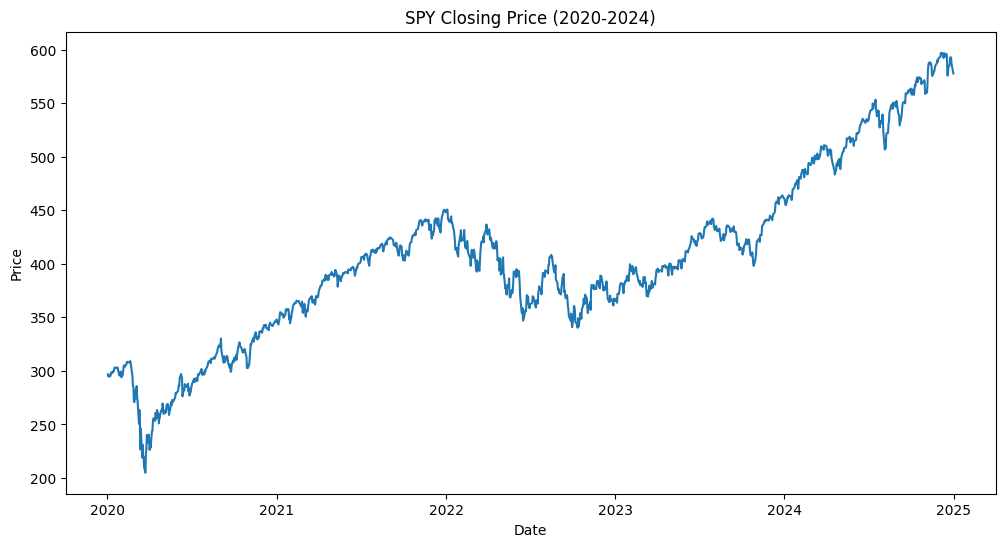

In [10]:
# ================================================
#         Plot SPY Closing Price
# ================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df[('Close','SPY')])

plt.title("SPY Closing Price (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

### SPY Price Trend Analysis

- The SPY ETF experienced a significant decline during the COVID-19 market crash in 2020, falling to approximately $205.

- After recovering, the market entered a strong upward trend and reached nearly $600 by the end of 2024. Although there were corrections during 2022, the long-term trend remained positive.



In [11]:
df.columns = df.columns.get_level_values(0)

print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [14]:
# ================================================
#         Create Daily Returns
# ================================================

df['Daily_Return'] = df['Close'].pct_change()

df[['Close','Daily_Return']].head(10)

Price,Close,Daily_Return
Date,,
2020-01-02,296.888123,NaN
2020-01-03,294.640106,-0.007572
2020-01-06,295.764130,0.003815
2020-01-07,294.932526,-0.002812
2020-01-08,296.504395,0.005330
2020-01-09,298.514801,0.006780
2020-01-10,297.655792,-0.002878
2020-01-13,299.702942,0.006878
2020-01-14,299.245941,-0.001525


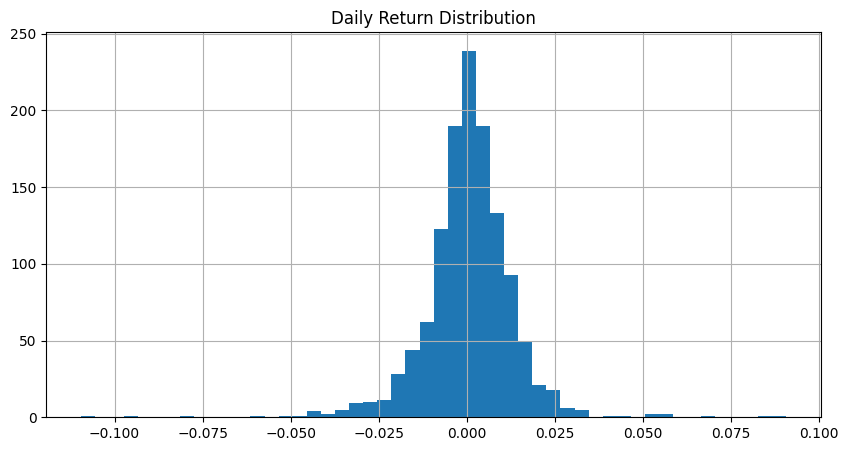

In [15]:
# ================================================
#         Visualize Daily Returns
# ================================================

plt.figure(figsize=(10,5))

df['Daily_Return'].hist(
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

### Daily Return Distribution Analysis

The daily returns are concentrated around zero, indicating that most trading days experience relatively small price changes. Large positive and negative returns occur infrequently and appear in the tails of the distribution. This suggests that predicting short-term stock movements is challenging because daily returns contain substantial noise.

In [16]:
# ================================================
#         Create Volatility
# ================================================

df['Volatility_20D'] = (
    df['Daily_Return']
    .rolling(20)
    .std()
)

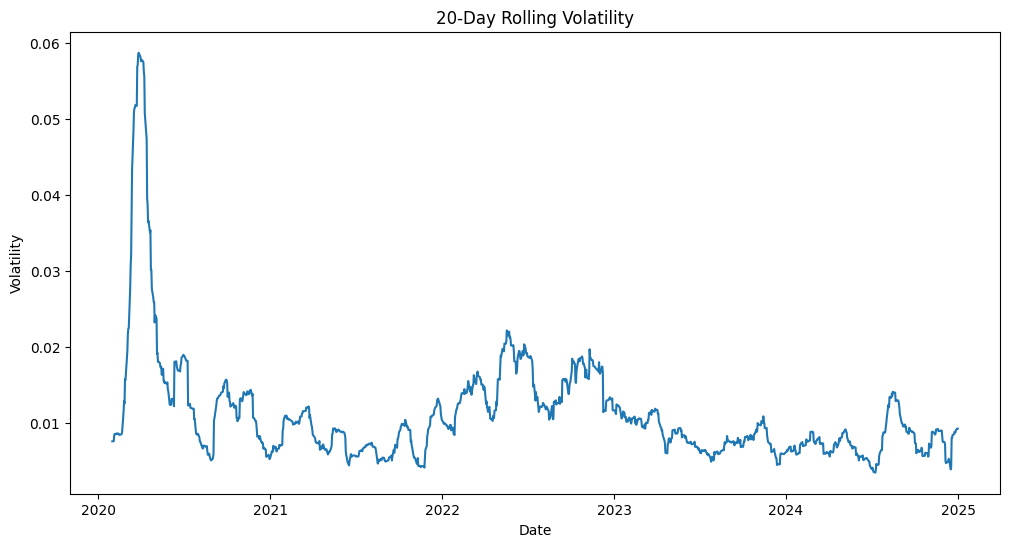

In [17]:
# ================================================
#         Plot Volatility
# ================================================

plt.figure(figsize=(12,6))

plt.plot(df['Volatility_20D'])

plt.title("20-Day Rolling Volatility")

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

### Volatility Analysis

The 20-day rolling volatility measures the variability of daily returns over the previous 20 trading days.

A significant volatility spike occurred in early 2020 during the COVID-19 market crash, indicating increased market uncertainty and risk.

Volatility gradually decreased after the crisis, although periodic increases occurred during market corrections. Overall, volatility remained lower during 2023 and 2024 compared to 2020.

# Feature Engineering

In [19]:
# ==================================================
#  Feature Engineering
# ==================================================

# Return_1D
df['Return_1D'] = df['Close'].pct_change()

# Return_5D
df['Return_5D'] = df['Close'].pct_change(5) # How much SPY changed over the last 5 trading days

# Return_10D
df['Return_10D'] = df['Close'].pct_change(10)

# Volatility_5D
df['Volatility_5D'] = (
    df['Return_1D']
    .rolling(5)
    .std()
)

# MA5
df['MA5'] = (
    df['Close']
    .rolling(5)
    .mean()
)

# MA20
df['MA20'] = (
    df['Close']
    .rolling(20)
    .mean()
)

# MA50
df['MA50'] = (
    df['Close']
    .rolling(50)
    .mean()
)

# MA Signal
df['MA_Signal'] = (
    df['MA5']
    -
    df['MA20']
)

# Volume Average
df['Volume_Avg_20'] = (
    df['Volume']
    .rolling(20)
    .mean()
)

# Volume Ratio
df['Volume_Ratio'] = (
    df['Volume']
    /
    df['Volume_Avg_20']
)

# Price vs MA20
df['Price_MA20_Ratio'] = (
    df['Close']
    /
    df['MA20']
)

# Target Variable
df['Tomorrow_Return'] = (
    df['Close']
    .pct_change()
    .shift(-1)
)

In [20]:
df[['Return_1D',
    'Return_5D',
    'Volatility_5D',
    'MA5',
    'MA20',
    'Volume_Ratio',
    'Tomorrow_Return'
]].head(30)

Price,Return_1D,Return_5D,Volatility_5D,MA5,MA20,Volume_Ratio,Tomorrow_Return
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,-0.007572
2020-01-03,-0.007572,NaN,NaN,NaN,NaN,NaN,0.003815
2020-01-06,0.003815,NaN,NaN,NaN,NaN,NaN,-0.002812
2020-01-07,-0.002812,NaN,NaN,NaN,NaN,NaN,0.005330
2020-01-08,0.005330,NaN,NaN,295.745856,NaN,NaN,0.006780
2020-01-09,0.006780,0.005479,0.006083,296.071191,NaN,NaN,-0.002878
2020-01-10,-0.002878,0.010235,0.004587,296.674329,NaN,NaN,0.006878
2020-01-13,0.006878,0.013317,0.005062,297.462091,NaN,NaN,-0.001525
2020-01-14,-0.001525,0.014625,0.004737,298.324774,NaN,NaN,0.002260


In [21]:
# ====================================
#        Check Missing Values
# ====================================

df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
Daily_Return,1
Volatility_20D,20
Return_1D,1
Return_5D,5


In [22]:
df = df.dropna()

In [23]:
df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
Daily_Return,0
Volatility_20D,0
Return_1D,0
Return_5D,0


# Feature Evaluation & Statistical Testing

In [24]:
features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

target = 'Tomorrow_Return'

In [25]:
corr_matrix = df[features + [target]].corr()

corr_matrix[target].sort_values(ascending=False)

,Tomorrow_Return
Price,
Tomorrow_Return,1.000000
Volatility_20D,0.042385
Volume_Ratio,-0.011809
Return_5D,-0.025177
MA_Signal,-0.027786
Volatility_5D,-0.035543
Return_10D,-0.037138
Price_MA20_Ratio,-0.046300
Return_1D,-0.132455


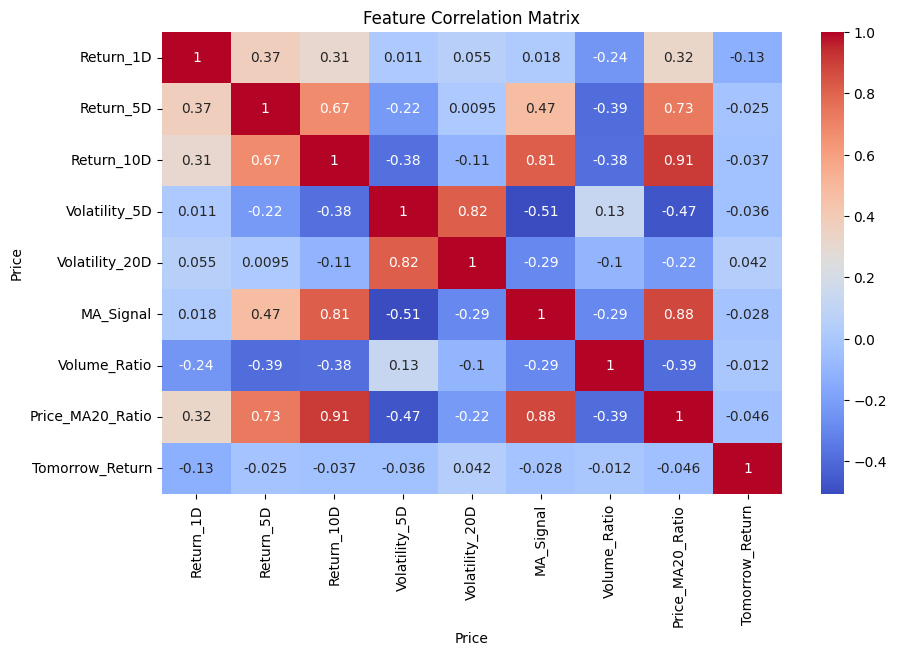

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

### Heatmap Interpretation

The correlation heatmap shows that most features have only weak direct relationships with future returns, which is expected in financial prediction problems.

Return_1D displayed the strongest relationship with Tomorrow_Return (-0.13), indicating a mild mean-reversion effect.

Several engineered features showed strong relationships with each other. For example:

- Return_10D and Price_MA20_Ratio had a correlation of 0.91
- MA_Signal and Price_MA20_Ratio had a correlation of 0.88
- Volatility_5D and Volatility_20D had a correlation of 0.82

These strong inter-feature relationships suggest possible multicollinearity, which should be considered during model building.

# Linear Regression Modeling I

In [27]:
features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

X = df[features]

y = df['Tomorrow_Return']

In [28]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [29]:
print(X_train.shape)
print(X_test.shape)

(966, 8)
(242, 8)


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [31]:
predictions = model.predict(X_test)

In [32]:
predictions[:10]

array([ 0.0023128 ,  0.00236604, -0.00059336, -0.00224465, -0.00093728,
       -0.00071931,  0.00016531, -0.00053573,  0.00137034, -0.00058815])

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("R2:", r2)

MSE: 6.764522632782065e-05
R2: -0.06556915722802659


In [35]:
# ================================================
#               Feature Importance
# ================================================
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
4,Volatility_20D,0.477131
1,Return_5D,0.008783
5,MA_Signal,-0.000130
6,Volume_Ratio,-0.000376
7,Price_MA20_Ratio,-0.003513
2,Return_10D,-0.005593
0,Return_1D,-0.157505
3,Volatility_5D,-0.481882


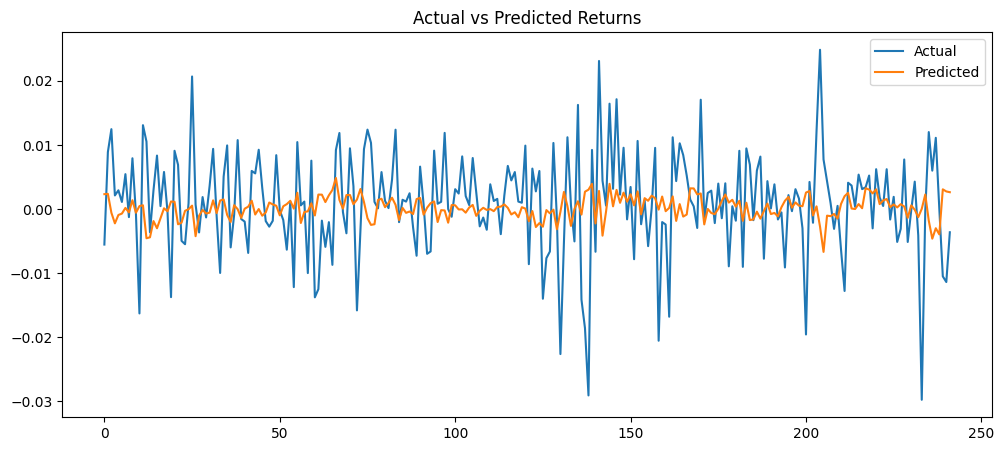

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Returns")

plt.show()

## Linear Regression Model Results

The linear regression model was trained using engineered return, volatility, trend, and volume features.

The model achieved:

- MSE = 6.76e-05
- R² = -0.0656

The negative R² score indicates that the model was unable to capture enough predictive information from the selected features.

Feature coefficient analysis suggests that volatility-related variables and short-term returns contributed most strongly to predictions.

The Actual vs Predicted plot shows that the model captures broad average behavior but fails to predict many short-term return fluctuations.

# Model Diagnostics & Improvement

In [37]:
# ================================================
#             Create Prediction DataFrame
# ================================================

results = pd.DataFrame({
    'Actual_Return': y_test,
    'Predicted_Return': predictions
})

results.head()

,Actual_Return,Predicted_Return
Date,,
2024-01-16,-0.005559,0.002313
2024-01-17,0.008893,0.002366
2024-01-18,0.012466,-0.000593
2024-01-19,0.002114,-0.002245
2024-01-22,0.002917,-0.000937


In [38]:
# ================================================
#             Create Trading Signal
# ================================================

import numpy as np

results['Signal'] = np.where(
    results['Predicted_Return'] > 0,
    1,
    -1
)

results.head()

,Actual_Return,Predicted_Return,Signal
Date,,,
2024-01-16,-0.005559,0.002313,1
2024-01-17,0.008893,0.002366,1
2024-01-18,0.012466,-0.000593,-1
2024-01-19,0.002114,-0.002245,-1
2024-01-22,0.002917,-0.000937,-1


In [39]:
# ================================================
#             Create Strategy Return
# ================================================

results['Strategy_Return'] = (
    results['Signal']
    *
    results['Actual_Return']
)

results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return
Date,,,,
2024-01-16,-0.005559,0.002313,1,-0.005559
2024-01-17,0.008893,0.002366,1,0.008893
2024-01-18,0.012466,-0.000593,-1,-0.012466
2024-01-19,0.002114,-0.002245,-1,-0.002114
2024-01-22,0.002917,-0.000937,-1,-0.002917


In [40]:
# ================================================
#             Create Equity Curve
# ================================================

results['Cumulative_Strategy'] = (
    1 + results['Strategy_Return']
).cumprod()

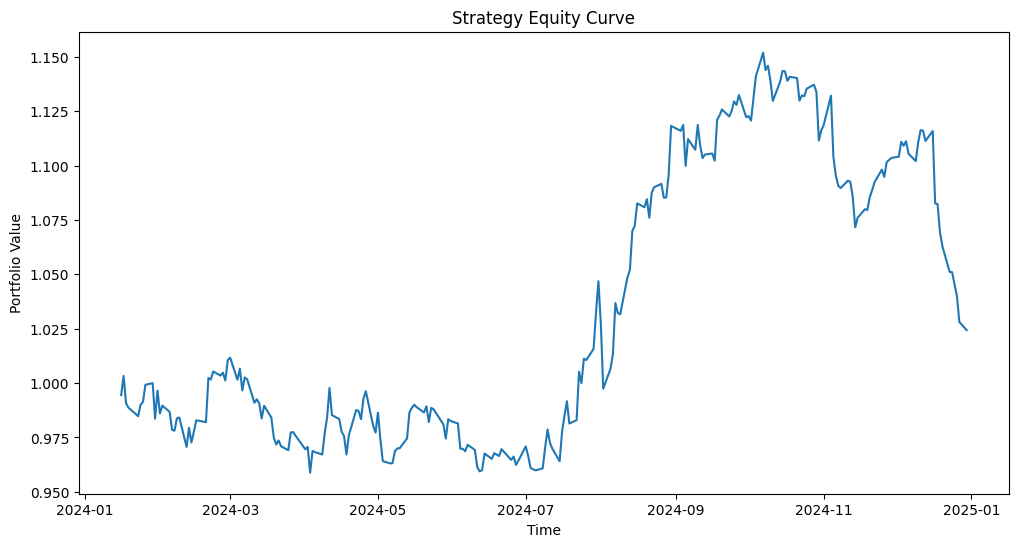

In [41]:
# ================================================
#             Plot Equity Curve
# ================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    results['Cumulative_Strategy']
)

plt.title("Strategy Equity Curve")

plt.ylabel("Portfolio Value")

plt.xlabel("Time")

plt.show()

In [42]:
# ================================================
#             Calculate Total Return
# ================================================

total_return = (
    results['Cumulative_Strategy'].iloc[-1] - 1
)

print("Total Return:", total_return)

Total Return: 0.02433046327989552


In [43]:
# ================================================
#             Calculate Win Rate
# ================================================

win_rate = (
    (results['Strategy_Return'] > 0)
    .mean()
)

print("Win Rate:", win_rate)

Win Rate: 0.5


In [44]:
# ================================================
#             Calculate Sharpe Ratio
# ================================================

sharpe = (
    results['Strategy_Return'].mean()
    /
    results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.25978709471913264


# Backtesting & Strategy Evaluation

## Performance Summary

The trading strategy was evaluated using a simple long-short framework based on Linear Regression predictions.

### Results

- Total Return: 2.43%
- Win Rate: 50%
- Sharpe Ratio: 0.26

### Interpretation

The strategy achieved a modest positive return over the test period. The win rate of 50% indicates that approximately half of the trading signals were profitable. The Sharpe Ratio of 0.26 suggests that the strategy's risk-adjusted performance is relatively weak.

Overall, the results demonstrate that the engineered features contain some predictive information, but additional feature engineering and more advanced machine learning models may be required to achieve stronger performance.

# Compare Multiple Machine Learning Models

In [45]:
# ============================================
#             Random Forest Model
# ============================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [46]:
# ============================================
#             Train Model
# ============================================

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
# ============================================
#             Predict
# ============================================

rf_predictions = rf_model.predict(X_test)

In [48]:
# ============================================
#           Evaluate Model
# ============================================

from sklearn.metrics import mean_squared_error, r2_score

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 6.89644711753629e-05
Random Forest R2: -0.0863503223846116


In [49]:
# ============================================
#           Compare With Linear Regression
# ============================================

comparison = {
    "Linear Regression MSE": mse,
    "Random Forest MSE": rf_mse,
    "Linear Regression R2": r2,
    "Random Forest R2": rf_r2
}

comparison

{'Linear Regression MSE': 6.764522632782065e-05,
 'Random Forest MSE': 6.89644711753629e-05,
 'Linear Regression R2': -0.06556915722802659,
 'Random Forest R2': -0.0863503223846116}

In [50]:
# ============================================
#          Feature Importance
# ============================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,Price_MA20_Ratio,0.158825
0,Return_1D,0.143434
4,Volatility_20D,0.140809
5,MA_Signal,0.128055
3,Volatility_5D,0.124112
1,Return_5D,0.109329
6,Volume_Ratio,0.102030
2,Return_10D,0.093407


In [51]:
# ============================================
#          Create Results DataFrame
# ============================================

rf_results = pd.DataFrame(index=y_test.index)

rf_results['Actual_Return'] = y_test
rf_results['Predicted_Return'] = rf_predictions

rf_results.head()

,Actual_Return,Predicted_Return
Date,,
2024-01-16,-0.005559,0.001228
2024-01-17,0.008893,0.003660
2024-01-18,0.012466,0.005491
2024-01-19,0.002114,-0.000110
2024-01-22,0.002917,0.000271


In [52]:
# ============================================
#          Create Buy/Sell Signals
# ============================================

rf_results['Signal'] = np.where(
    rf_results['Predicted_Return'] > 0,
    1,
    -1
)

rf_results.head()

,Actual_Return,Predicted_Return,Signal
Date,,,
2024-01-16,-0.005559,0.001228,1
2024-01-17,0.008893,0.003660,1
2024-01-18,0.012466,0.005491,1
2024-01-19,0.002114,-0.000110,-1
2024-01-22,0.002917,0.000271,1


In [53]:
# ============================================
#          Calculate Strategy Return
# ============================================

rf_results['Strategy_Return'] = (
    rf_results['Signal']
    *
    rf_results['Actual_Return']
)

rf_results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return
Date,,,,
2024-01-16,-0.005559,0.001228,1,-0.005559
2024-01-17,0.008893,0.003660,1,0.008893
2024-01-18,0.012466,0.005491,1,0.012466
2024-01-19,0.002114,-0.000110,-1,-0.002114
2024-01-22,0.002917,0.000271,1,0.002917


In [54]:
# ============================================
#          Build Equity Curve
# ============================================

rf_results['Cumulative_Strategy'] = (
    1 + rf_results['Strategy_Return']
).cumprod()

rf_results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return,Cumulative_Strategy
Date,,,,,
2024-01-16,-0.005559,0.001228,1,-0.005559,0.994441
2024-01-17,0.008893,0.003660,1,0.008893,1.003285
2024-01-18,0.012466,0.005491,1,0.012466,1.015792
2024-01-19,0.002114,-0.000110,-1,-0.002114,1.013644
2024-01-22,0.002917,0.000271,1,0.002917,1.016601


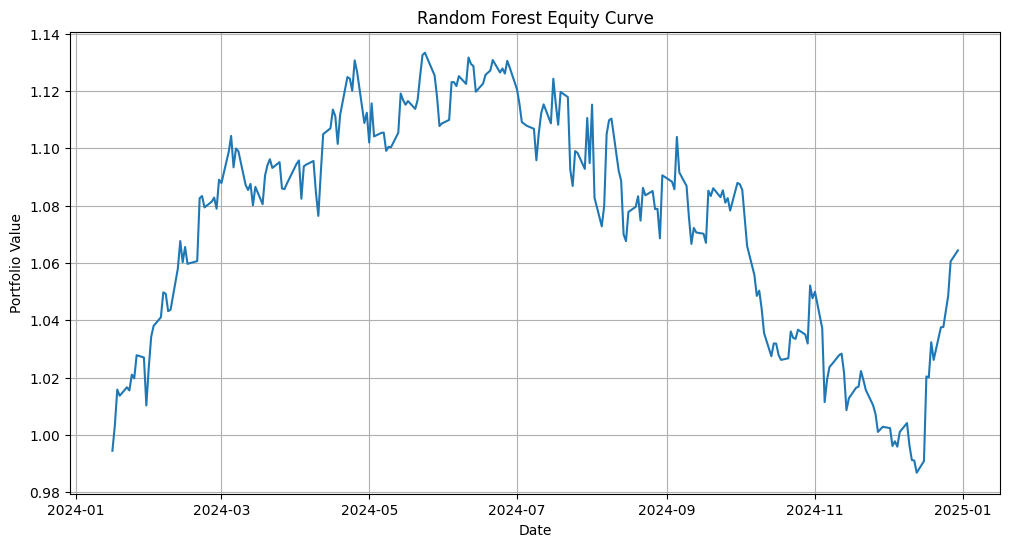

In [55]:
# ============================================
#          Plot Equity Curve
# ============================================

plt.figure(figsize=(12,6))

plt.plot(
    rf_results.index,
    rf_results['Cumulative_Strategy']
)

plt.title("Random Forest Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.show()

In [56]:
# ============================================
#          Calculate Total Return
# ============================================

rf_total_return = (
    rf_results['Cumulative_Strategy'].iloc[-1]
    - 1
)

print("Total Return:", rf_total_return)

Total Return: 0.06435492270677434


In [57]:
# ============================================
#          Calculate Win Rate
# ============================================

rf_win_rate = (
    rf_results['Strategy_Return'] > 0
).mean()

print("Win Rate:", rf_win_rate)

Win Rate: 0.49173553719008267


In [58]:
# ============================================
#         Calculate Sharpe Ratio
# ============================================
rf_sharpe = (
    rf_results['Strategy_Return'].mean()
    /
    rf_results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", rf_sharpe)

Sharpe Ratio: 0.572651029683957


In [59]:
# ============================================
#         Final Comparison Table
# ============================================
final_comparison = pd.DataFrame({
    'Metric': [
        'MSE',
        'R2',
        'Total Return',
        'Win Rate',
        'Sharpe Ratio'
    ],
    'Linear Regression': [
        mse,
        r2,
        total_return,
        win_rate,
        sharpe
    ],
    'Random Forest': [
        rf_mse,
        rf_r2,
        rf_total_return,
        rf_win_rate,
        rf_sharpe
    ]
})

final_comparison

,Metric,Linear Regression,Random Forest
0,MSE,0.000068,0.000069
1,R2,-0.065569,-0.086350
2,Total Return,0.024330,0.064355
3,Win Rate,0.500000,0.491736
4,Sharpe Ratio,0.259787,0.572651


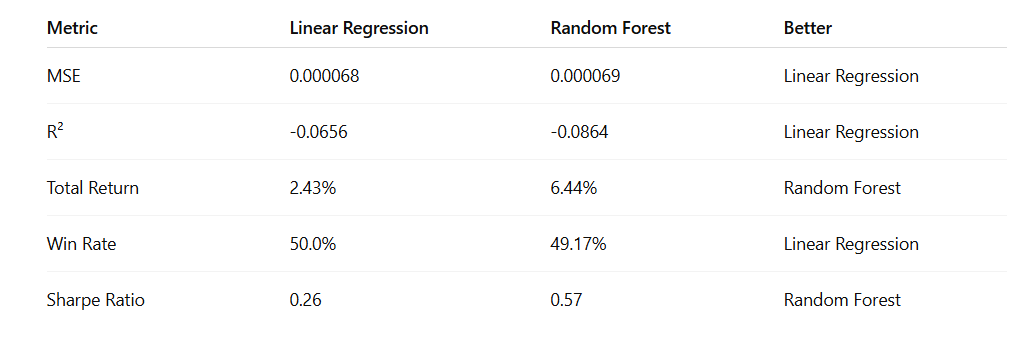

# Random Forest Classifier

In [60]:
# ============================================
# Create Classification Target
# ============================================

df['Target'] = np.where(
    df['Tomorrow_Return'] > 0,
    1,
    0
)

In [61]:
# ===========================================
#           Check Class Distribution
# ===========================================

df['Target'].value_counts()

,count
Target,
1,664
0,544


In [62]:
# ===========================================
#           Create Features
# ===========================================

features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

In [63]:
# ===========================================
#           Create X and y
# ===========================================

X = df[features]

y = df['Target']

In [64]:
# ===========================================
#           Remove Missing Values
# ===========================================

classification_df = pd.concat(
    [X, y],
    axis=1
).dropna()

In [65]:
# ===========================================
#           Rebuild X and y
# ===========================================

X = classification_df[features]

y = classification_df['Target']

In [66]:
# ===========================================
#          Train/Test Split
# ===========================================

split = int(len(classification_df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [67]:
# ===========================================
#          Check Shapes
# ===========================================

print(X_train.shape)
print(X_test.shape)

(966, 8)
(242, 8)


In [68]:
# ===========================================
#          Import Classifier
# ===========================================

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [69]:
# ===========================================
#          Train Model
# ===========================================

rf_classifier.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [70]:
# ===========================================
#          Predict
# ===========================================

predictions = rf_classifier.predict(X_test)

In [71]:
# ===========================================
#          Accuracy
# ===========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.5206611570247934


In [72]:
# ===========================================
#        Confusion Matrix
# ===========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[42 56]
 [60 84]]


In [73]:
# ===========================================
#        Classification Report
# ===========================================
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.41      0.43      0.42        98
           1       0.60      0.58      0.59       144

    accuracy                           0.52       242
   macro avg       0.51      0.51      0.51       242
weighted avg       0.52      0.52      0.52       242



In [74]:
# ===========================================
#        Create Feature Importance
# ===========================================
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_classifier.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Return_1D,0.132329
1,Return_5D,0.132074
4,Volatility_20D,0.126037
6,Volume_Ratio,0.124563
5,MA_Signal,0.123573
7,Price_MA20_Ratio,0.121723
3,Volatility_5D,0.121306
2,Return_10D,0.118395


In [75]:
# ===========================================
#        Create Results DataFrame
# ===========================================
results = pd.DataFrame(
    index=y_test.index
)

results['Prediction'] = predictions

results.head()

,Prediction
Date,
2024-01-16,1
2024-01-17,1
2024-01-18,1
2024-01-19,1
2024-01-22,1


In [76]:
# ===========================================
#     Convert Prediction to Trading Signal
# ===========================================
results['Signal'] = np.where(
    results['Prediction'] == 1,
    1,
    -1
)

In [77]:
# ===========================================
#     Add Actual Returns
# ===========================================
results['Actual_Return'] = (
    df.loc[
        results.index,
        'Tomorrow_Return'
    ]
)

In [78]:
# ===========================================
#     Calculate Strategy Return
# ===========================================
results['Strategy_Return'] = (
    results['Signal']
    *
    results['Actual_Return']
)

In [79]:
# ===========================================
#    Build Equity Curve
# ===========================================
results['Cumulative_Strategy'] = (
    1 + results['Strategy_Return']
).cumprod()

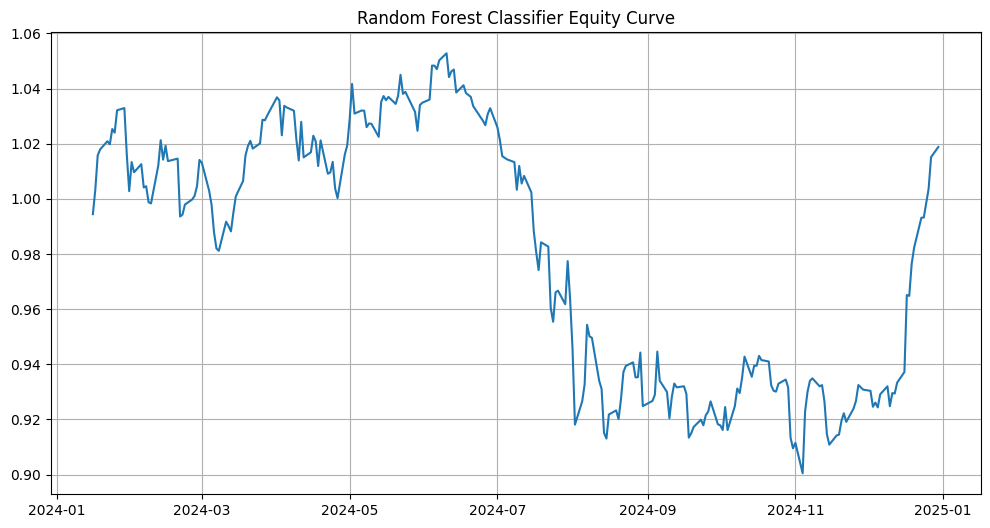

In [81]:
# ===========================================
#   Plot Equity Curve
# ===========================================
plt.figure(figsize=(12,6))

plt.plot(
    results.index,
    results['Cumulative_Strategy']
)

plt.title(
    "Random Forest Classifier Equity Curve"
)

plt.grid(True)

plt.show()

In [82]:
# ===========================================
#   Calculate exact metrics
# ===========================================
total_return = (
    results['Cumulative_Strategy'].iloc[-1] - 1
)

print("Total Return:", total_return)

Total Return: 0.018836170111071526


In [83]:
# ===========================================
#   Calculate Win rate
# ===========================================
win_rate = (
    results['Strategy_Return'] > 0
).mean()

print("Win Rate:", win_rate)

Win Rate: 0.5206611570247934


In [84]:
# ===========================================
#   Calculate Sharpe Ratio
# ===========================================
sharpe = (
    results['Strategy_Return'].mean()
    /
    results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.21585501516090072


In [85]:
final_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor',
        'Random Forest Classifier'
    ],
    'Total Return': [
        0.02433,
        0.06435,
        total_return
    ]
})

final_comparison

,Model,Total Return
0,Linear Regression,0.024330
1,Random Forest Regressor,0.064350
2,Random Forest Classifier,0.018836


# Model Ranking

## 🥇 1st Place: Random Forest Regressor

### Why it Ranked #1
- Highest Total Return (**6.44%**)
- Highest Sharpe Ratio (**0.573**)
- Best overall trading performance among all models

### Interpretation
The Random Forest Regressor successfully captured nonlinear relationships in the SPY market data and generated the strongest trading strategy. Although its R² score was still negative, the model produced the highest cumulative return and best risk-adjusted performance, making it the top-performing model in this project.

---

## 🥈 2nd Place: Linear Regression

### Performance
- Total Return: **2.43%**
- Sharpe Ratio: **0.260**

### Interpretation
Linear Regression provided a simple baseline model for predicting next-day returns. While it did not capture complex market patterns, it generated positive returns and performed better than the Random Forest Classifier. Its simplicity and interpretability make it a useful benchmark model.

---

## 🥉 3rd Place: Random Forest Classifier

### Performance
- Accuracy: **52.07%**
- Total Return: **1.88%**
- Sharpe Ratio: **0.216**

### Interpretation
The Random Forest Classifier achieved the highest directional prediction accuracy, correctly identifying market direction slightly more than half the time. However, higher classification accuracy did not translate into stronger trading performance. The resulting strategy produced the lowest return and Sharpe Ratio among the three models.

---

# Overall Conclusion

The results demonstrate that prediction accuracy alone is not sufficient when evaluating financial trading models. Although the Random Forest Classifier achieved the highest accuracy, the Random Forest Regressor generated substantially better investment performance.

Based on Total Return, Sharpe Ratio, and overall portfolio growth, the **Random Forest Regressor** was selected as the best-performing model for SPY return prediction and trading strategy development.

### Final Ranking

| Rank | Model | Best Metric |
|--------|--------|--------|
| 🥇 1 | Random Forest Regressor | Highest Return & Sharpe Ratio |
| 🥈 2 | Linear Regression | Simple and Stable Baseline |
| 🥉 3 | Random Forest Classifier | Highest Accuracy |

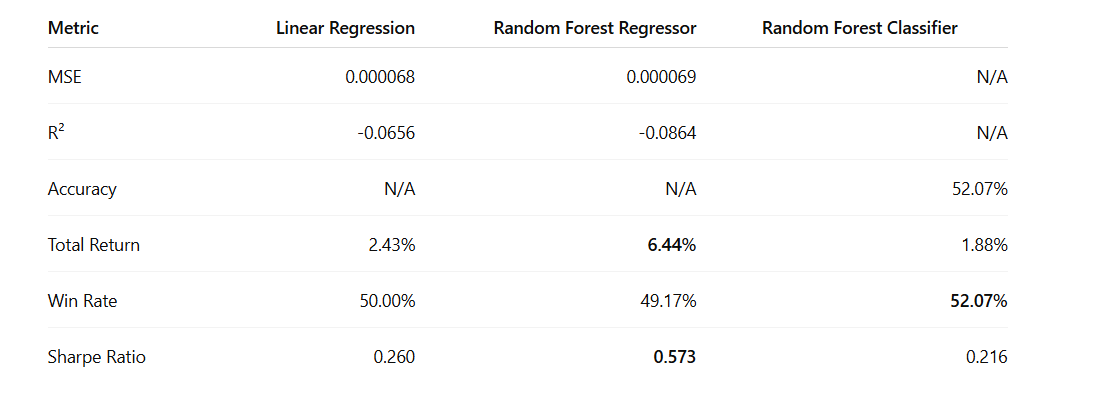

# Final Conclusions

## Project Summary

This project developed and evaluated machine learning models for predicting next-day returns of the SPY ETF using technical indicators derived from historical market data between 2020 and 2024.

The analysis included exploratory data analysis, feature engineering, statistical evaluation, model development, and trading strategy backtesting.

## Models Evaluated

- Linear Regression
- Random Forest Regressor
- Random Forest Classifier

## Best Model

The Random Forest Regressor achieved the strongest overall trading performance.

### Performance

- Total Return: 6.44%
- Sharpe Ratio: 0.573

## Key Findings

- Technical indicators contain some predictive information.
- Higher prediction accuracy does not always lead to higher trading returns.
- Random Forest Regressor produced the best risk-adjusted performance.
- Feature importance analysis showed that Price_MA20_Ratio, Return_1D, and Volatility_20D were the most influential features.

## Future Improvements

- XGBoost Models
- Hyperparameter Tuning
- Additional Technical Indicators
- Deep Learning Models (LSTM)
- Multi-Asset Portfolio Strategies

## Conclusion

Among all models tested, the Random Forest Regressor delivered the best overall investment performance and was selected as the final model for the trading strategy.